In [26]:
print("\n TASK 1: Unemployment Analysis with Python \n")


 TASK 1: Unemployment Analysis with Python 



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

df = pd.read_csv("Unemployment in India.csv")
df.columns = df.columns.str.strip()

df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [14]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [24]:
#Data Cleaning
df = df.dropna()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
print(df.shape)

(740, 7)


In [17]:
#Data Analysis
print(df["Estimated Unemployment Rate (%)"].describe())

count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


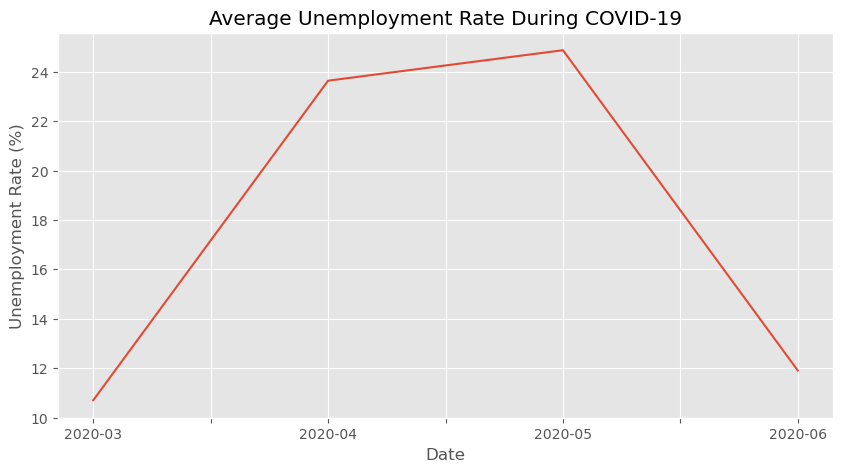

In [18]:
#Covid-19 Impact Analysis
covid = df[df["Date"] >= "2020-03-01"]

monthly = covid.groupby(
    covid["Date"].dt.strftime("%Y-%m")
)["Estimated Unemployment Rate (%)"].mean()

monthly.plot(figsize=(10,5))
plt.title("Average Unemployment Rate During COVID-19")
plt.ylabel("Unemployment Rate (%)")
plt.show()

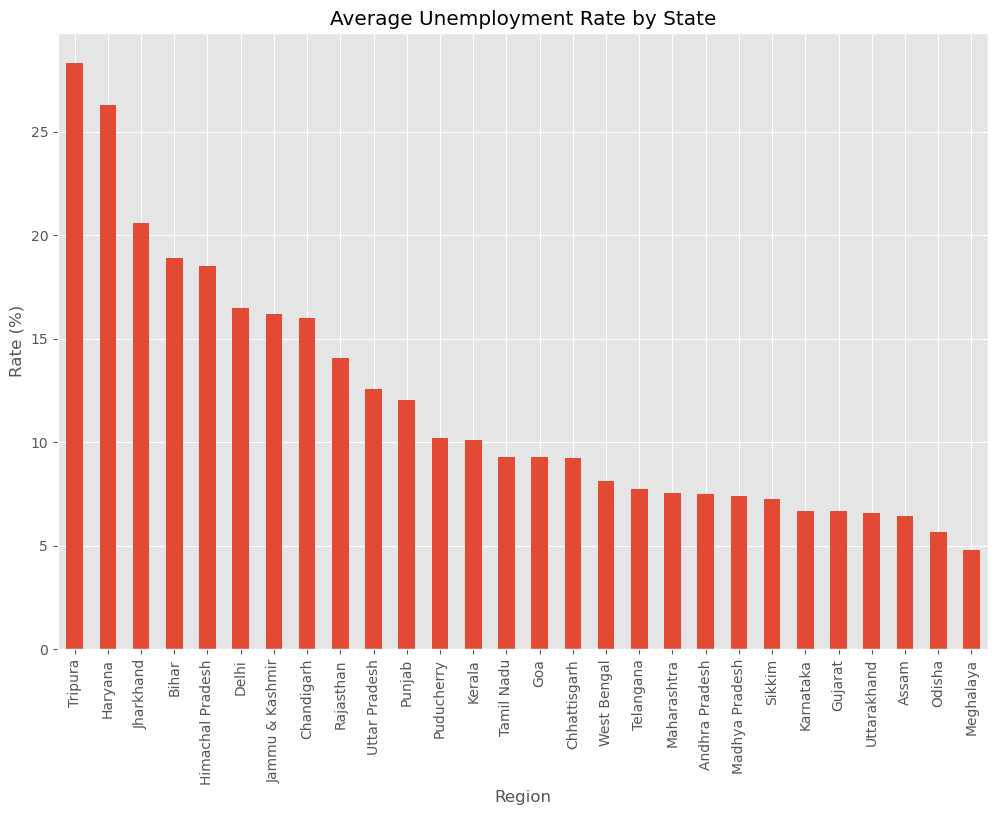

In [19]:
#State-Wise Analysis
state_unemployment = df.groupby("Region")[
    "Estimated Unemployment Rate (%)"
].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
state_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by State")
plt.ylabel("Rate (%)")
plt.show()

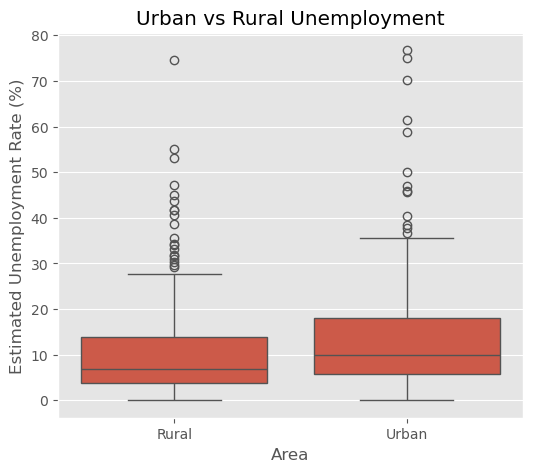

In [21]:
#Urban vs Rural Analysis
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Area",
    y="Estimated Unemployment Rate (%)",
    data=df
)
plt.title("Urban vs Rural Unemployment")
plt.show()

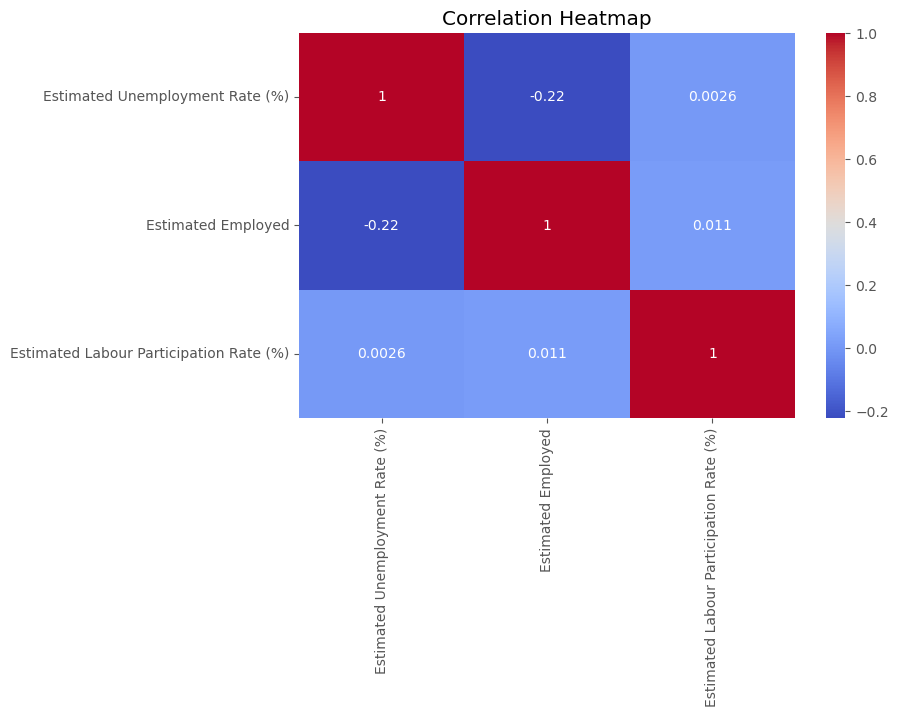

In [22]:
#Correlation Heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()